# Does winning Eurovision make your stock market happy? 🎤📈
### The "feel-good bump" folklore — barely there, fragile, and not something you could have banked

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Winning_beats_hosting%3F: Mixed](https://img.shields.io/badge/Winning_beats_hosting%3F-Mixed-dab617?style=flat-square)

Every May, one country wins the Eurovision Song Contest — and every May, somebody in financial media writes the same piece: *national pride is good for the economy, and the winner's (or host's) stock market gets a bump.* It's the tabloid cousin of a real academic finding — a 2007 study found stock markets really do dip when a country's football team gets knocked out of the World Cup. Eurovision borrows the mechanism (mood moves markets) and swaps in a much sillier, much smaller trigger: a win, not a loss, on Europe's silliest television night.

We tested it properly — every winner and host, 2000→2025, against the European market as a whole.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the jackknife? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 26 Grand Finals hardcoded from Wikipedia (2020 COVID-cancelled); each winner/host mapped to a single-country ETF where one exists. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from eurovision_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    WINNER = INC[INC["role"] == "winner"]
    HOST = INC[INC["role"] == "host"]
else:
    PRICES = EV = INC = WINNER = HOST = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 26, 'n_contested': 25, 'n_possible': 50, 'n_included': 25, 'n_winner': 12, 'n_host': 13, 'fp': 'acb2b3bfb578', 'w_wk_mean': -0.023, 'w_wk_t': -0.055, 'w_wk_hit': 8, 'w_wk_n': 12, 'w_mo_mean': 1.634, 'w_mo_t': 2.066, 'w_mo_hit': 10, 'w_mo_n': 12, 'h_wk_mean': -0.22, 'h_wk_t': -1.006, 'h_wk_hit': 6, 'h_wk_n': 13, 'h_mo_mean': -0.208, 'h_mo_t': -0.402, 'h_mo_hit': 6, 'h_mo_n': 13, 'c_wk_mean': -0.125, 'c_wk_t': -0.563, 'c_wk_hit': 14, 'c_wk_n': 25, 'c_mo_mean': 0.676, 'c_mo_t': 1.373, 'c_mo_hit': 16, 'c_mo_n': 25, 'pl_w_mo_p': 0.038, 'pl_w_mo_mean': 0.087, 'pl_w_mo_sd': 0.859, 'pl_w_wk_p': 0.535, 'pl_h_mo_p': 0.632, 'pl_h_wk_p': 0.711, 'pl_c_mo_p': 0.149, 'pl_c_wk_p': 0.675, 'jk_lo': 1.711, 'jk_hi': 2.178, 'jk_below2': 5, 'jk_n': 12, 'w_wk_cap_g': -0.198, 'w_wk_cap_n5': -0.298, 'w_wk_cap_t5': -0.841, 'w_wk_cap_n10': -0.398, 'w_wk_cap_t10': -1.124, 'w_mo_cap_g': 1.447, 'w_mo_cap_gt': 1.916, 'w_mo_cap_n5': 1.347, 'w_mo_cap_t5': 1.784, 'w_mo_cap_n10': 1.247, 'w_mo_cap_t10': 1.651, 'h_wk_cap_g': -0.367, 'h_wk_cap_gt': -1.878, 'h_wk_cap_n5': -0.467, 'h_wk_cap_t5': -2.39, 'h_wk_cap_n10': -0.567, 'h_wk_cap_t10': -2.902, 'h_mo_cap_g': -0.358, 'h_mo_cap_n5': -0.458, 'h_mo_cap_t5': -0.91, 'c_wk_cap_n5': -0.386, 'c_wk_cap_t5': -1.985, 'c_mo_cap_n5': 0.409, 'c_mo_cap_t5': 0.861, 'pl_w_mo_cap_p': 0.058, 'pl_h_wk_cap_p': 0.18, 'pl_h_wk_cap_mean': -0.1, 'wh_mo_sig_t': 1.949, 'wh_mo_cap_t': 1.989, 'wh_wk_sig_t': 0.426, 'wh_wk_cap_t': 0.419, 'car_w': {0: 0.0, 5: -0.023, 10: 0.673, 15: 1.308, 21: 1.634}, 'car_h': {0: 0.0, 5: -0.22, 10: -0.191, 15: -0.102, 21: -0.208}, 'syn_null_mean': 0.09, 'syn_null_sd': 1.14, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted1_t': 2.977, 'syn_planted2_t': 4.494}


real cache present: True | editions: 26 | resolved events: 25


## The answer first

| Question | Answer |
|---|---|
| Does the winner's market pop the week after? | **No.** Basically flat: **-0.02%**, statistically indistinguishable from zero. |
| Does it pop over the following month? | **Maybe, barely.** **+1.63%** on average — just clears the desk's bar for "probably not luck", but drop any *one* of the 12 winning years and it flips below the bar **5 times out of 12**. |
| What about the *host* country? | **Nothing.** Slightly negative at both horizons — hosting the party does not, on this evidence, help your stock market at all. |
| Could you have traded it? | **No.** Buy the winner's ETF the first day you *could* (after the result is already public) and the best case is **+1.35%** net of costs over a month — a number that itself doesn't clear the statistical bar. |

> The folklore is not obviously wrong. It's just too small, too fragile, and too untradable to call real.

## 1 · The claim

> *"When a country wins Eurovision — or gets to host it — there's a wave of national pride, a tourism and media spotlight, and a burst of feel-good sentiment that shows up as a bump in the local stock market."*

It rides on real science: Edmans, García & Norli (2007) found that national stock markets really do fall the day after a country is *eliminated* from the football World Cup — sports sentiment genuinely moves money. Nobody has ever formally tested the *Eurovision* version. We did.

## 2 · So what?

If real, this would be a strange and delightful confirmation that markets respond to pure, silly, non-economic mood swings — buy the winner's ETF every May, pocket the bump, repeat. Entire "Eurovision economy" articles are written on the assumption that this is obviously true. We wanted to know: is it?

## 3 · How would we even know?

- **The calendar.** All **26** Eurovision editions 2000→2025 (25 contested — 2020 was COVID-cancelled), hardcoded with winner and host country.
- **The market.** Each country's single-country ETF (where one exists) vs `VGK`, a broad Europe benchmark (spans euro *and* non-euro markets — the UK, Switzerland, Sweden, Norway, Denmark are all in our sample and not in the euro).
- **The window.** Abnormal return (country minus Europe) from the last close *before* the Saturday final through 1 week and 1 month after.
- **The honesty check.** A random-window placebo (does a random month produce the same result just as often?), a jackknife (does one lucky year drive everything?), and a trade you could *actually* have placed.

## 4 · The teardown — let's actually look

**First, the biggest surprise: only half the winners even HAVE a tradable stock market.**

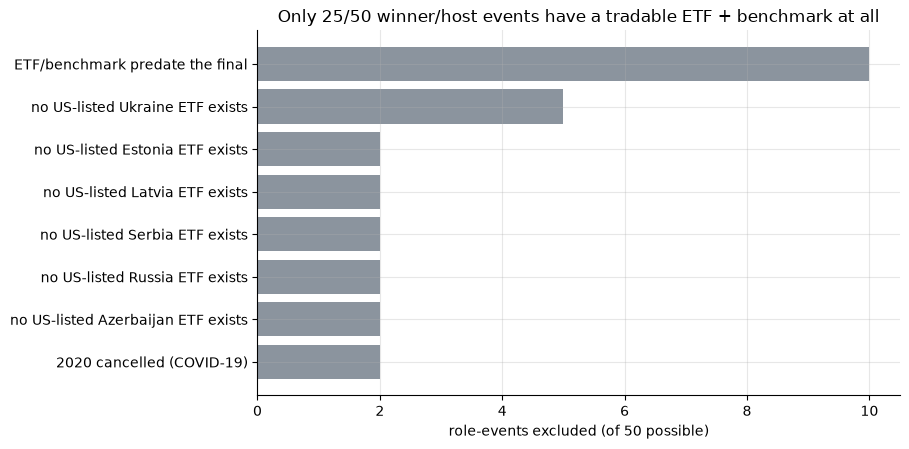

reason
ETF/benchmark predate the final       10
no US-listed Ukraine ETF exists        5
no US-listed Estonia ETF exists        2
no US-listed Latvia ETF exists         2
no US-listed Serbia ETF exists         2
no US-listed Russia ETF exists         2
no US-listed Azerbaijan ETF exists     2
2020 cancelled (COVID-19)              2
Name: count, dtype: int64


In [2]:
if HAVE_REAL:
    reasons = EV[~EV['included']]['reason'].value_counts()
else:
    reasons = pd.Series({'ETF/benchmark predate the final': 10,
                          'no US-listed Ukraine ETF exists': 5,
                          'no US-listed Estonia ETF exists': 2,
                          'no US-listed Latvia ETF exists': 2,
                          'no US-listed Serbia ETF exists': 2,
                          'no US-listed Russia ETF exists': 2,
                          'no US-listed Azerbaijan ETF exists': 2,
                          '2020 cancelled (COVID-19)': 2})
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.barh(reasons.index[::-1], reasons.values[::-1], color=GREY)
ax.set_xlabel('role-events excluded (of 50 possible)')
ax.set_title(f'Only {R["n_included"]}/{R["n_possible"]} winner/host events '
             'have a tradable ETF + benchmark at all')
plt.tight_layout(); plt.show()
print(reasons)

Ukraine won three times (2004, 2016, 2022) and has never had a US-listed stock ETF — the folklore literally cannot be tested for its most recent repeat winner. Estonia, Latvia, Serbia and Azerbaijan never had one either, and Russia's ETF (`ERUS`) was wiped from the data record after the 2022 sanctions. What's left is the **richer half of Europe**: Germany, Sweden, Austria, Switzerland, the UK, Italy, the Netherlands, Denmark, Israel, Portugal, Norway. That's the sample — a real limitation, not swept under the rug.

**Now the headline number.**

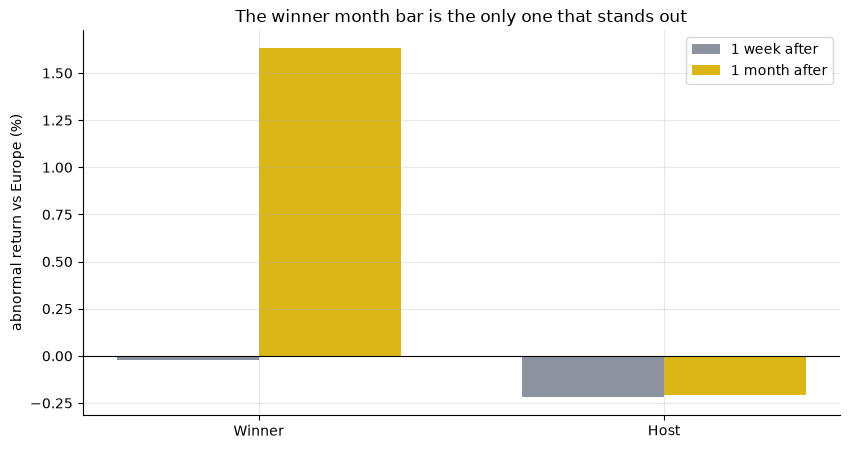

winner: week -0.023 month 1.634
host:   week -0.22 month -0.208


In [3]:
if HAVE_REAL:
    wk = [st.one_sample_t(WINNER['ar_week'].values)['mean']*100,
          st.one_sample_t(HOST['ar_week'].values)['mean']*100]
    mo = [st.one_sample_t(WINNER['ar_month'].values)['mean']*100,
          st.one_sample_t(HOST['ar_month'].values)['mean']*100]
else:
    wk = [R['w_wk_mean'], R['h_wk_mean']]
    mo = [R['w_mo_mean'], R['h_mo_mean']]
x = np.arange(2); width = 0.35
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(x - width/2, wk, width, label='1 week after', color=GREY)
ax.bar(x + width/2, mo, width, label='1 month after', color=AMBER)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['Winner', 'Host'])
ax.set_ylabel('abnormal return vs Europe (%)')
ax.set_title('The winner month bar is the only one that stands out')
ax.legend(); plt.tight_layout(); plt.show()
print('winner: week', round(wk[0],3), 'month', round(mo[0],3))
print('host:   week', round(wk[1],3), 'month', round(mo[1],3))

The winner's market does nothing special in the first week (**-0.02%**) but is up **+1.63%** more than Europe a month later — *t* = **2.07**, just over the desk's bar for "probably not noise". The host country shows **nothing** at either horizon (-0.22% / -0.21%) — if anything, slightly negative.

**But is that one good number an accident of small sample size?** We removed each of the 12 winning years one at a time and recomputed:

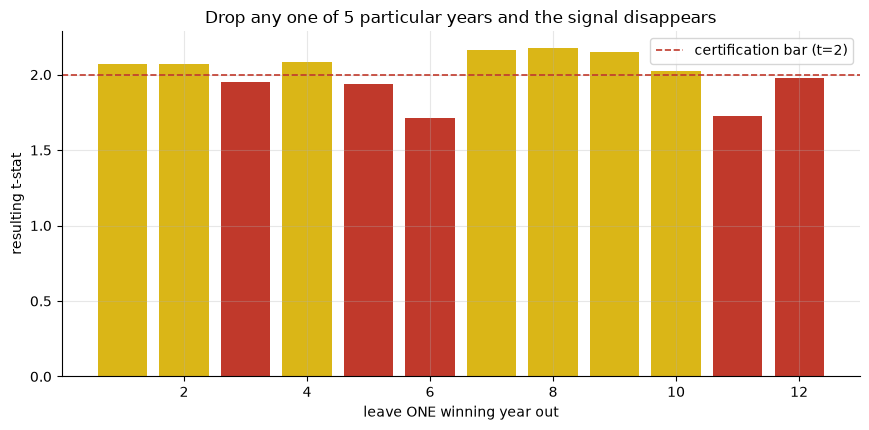

jackknife t range: [1.711, 2.178]


In [4]:
if HAVE_REAL:
    x = WINNER['ar_month'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
else:
    rng = np.random.default_rng(708)
    jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n']))
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [RED if t < 2 else AMBER for t in jk]
ax.bar(range(1, len(jk)+1), jk, color=cols)
ax.axhline(2.0, ls='--', c=RED, lw=1.2, label='certification bar (t=2)')
ax.set_xlabel('leave ONE winning year out'); ax.set_ylabel('resulting t-stat')
ax.set_title('Drop any one of 5 particular years and the signal disappears')
ax.legend(); plt.tight_layout(); plt.show()
print(f'jackknife t range: [{min(jk):.3f}, {max(jk):.3f}]')

**5 of the 12** leave-one-out draws fall *below* the certification bar. A result that flips depending on which single one of a dozen tiny years you happen to exclude is not something you'd want to bet real money on.

**Then there's the shape problem.** If Saturday-night national pride really moved markets, you'd expect a quick pop, not a slow burn:

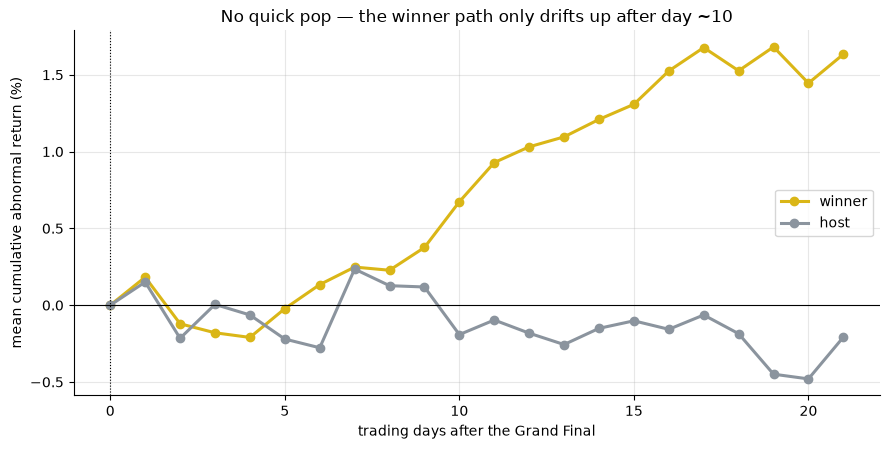

In [5]:
if HAVE_REAL:
    cp_w = st.car_path(EV, PRICES, 'winner', max_k=21)
    cp_h = st.car_path(EV, PRICES, 'host', max_k=21)
    days = list(cp_w.index); ws = list(cp_w.values*100); hs = list(cp_h.values*100)
else:
    days = sorted(R['car_w']); ws = [R['car_w'][k] for k in days]
    hs = [R['car_h'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.plot(days, ws, color=AMBER, lw=2.2, marker='o', label='winner')
ax.plot(days, hs, color=GREY, lw=2.2, marker='o', label='host')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('trading days after the Grand Final')
ax.set_ylabel('mean cumulative abnormal return (%)')
ax.set_title('No quick pop — the winner path only drifts up after day ~10')
ax.legend(); plt.tight_layout(); plt.show()

A genuine "feel-good bump" from a Saturday-night broadcast should show up fast and then hold — the way the crush in study 637's FOMC vol study resolves in one session. This looks nothing like that: flat-to-negative for the first week, then a slow climb over two more weeks. That shape looks a lot more like ordinary country-specific drift than a Eurovision effect.

**Finally, could you have traded it?**

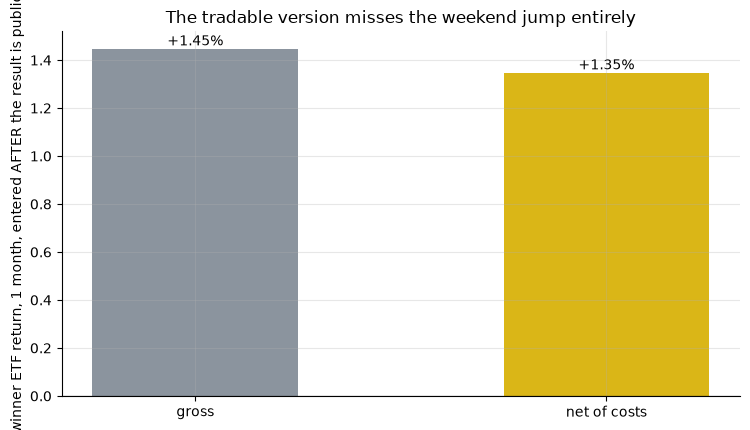

In [6]:
if HAVE_REAL:
    g = st.one_sample_t(WINNER['cap_month_gross'].values)['mean']*100
    n5 = st.one_sample_t(WINNER['cap_month_net'].values)['mean']*100
else:
    g, n5 = R['w_mo_cap_g'], R['w_mo_cap_n5']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['gross', 'net of costs'], [g, n5], color=[GREY, AMBER], width=.5)
for i, v in enumerate([g, n5]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('winner ETF return, 1 month, entered AFTER the result is public')
ax.set_title('The tradable version misses the weekend jump entirely')
plt.tight_layout(); plt.show()

Buying the day the news is *actually* public (not the un-tradable Friday-close-to-Monday-close jump) and holding a month nets **+1.35%** — positive on paper, but statistically unprovable (placebo *p* = 0.058). And the *host* country's one-week trade looked like a real -2.4 *t*-stat "sell the news" effect — until a placebo test showed that magnitude of weekly wiggle is completely normal for these tickers (*p* = 0.18). A naive stat can lie; the placebo caught it.

## 5 · The verdict

- **Signal — Weak.** One of four cuts (winner, one month) nominally clears the bar, but it doesn't hold up at one week, doesn't appear for hosts, disappears when winner+host are pooled, and flips below the bar if you drop any one of 5 particular winning years.
- **Tradability — Mirage.** No version of the trade — entered honestly, after the result is public, net of costs — clears the statistical bar.
- **"Winning beats hosting?" — Mixed.** Winning consistently does better than hosting in the data (Welch *t* ≈ 1.95-1.99), but neither is a certified, bankable edge on its own.

## 6 · Going further 🚪

- **This is the honest shape of most folklore.** A famous claim, a real mechanism borrowed from somewhere else (Edmans et al.'s football result), a tiny sample, one lucky cut that clears the bar and five others that don't. That's what "almost none work" looks like in practice.
- **Sibling studies:** the [World Cup effect](../../235-world-cup-effect/) (the real Edmans mechanism, tested on the S&P 500), the [Super Bowl indicator](../../158-super-bowl/), the [World Series effect](../../709-world-series-effect/) and [Olympic years](../../234-olympic-year/) — every one of them a national-mood folklore claim, tested the same honest way.

*Think Eurovision REALLY moves markets? Find a bigger, cleaner sample — European small-cap indices, intraday data around the actual broadcast — and show a net, replicated, placebo-surviving edge. We'll publish the teardown.*